# EDA — Yield Patterns

Goal: identify sensor-level signals that separate passing from failing wafers and build empirical hypotheses for validation by Tier 3 (SHAP global rankings in `src/yield_risk/explainability.py` and root-cause triage in `src/yield_risk/root_cause.py`). The analysis loads the preprocessed splits from `data/processed/`, computes point-biserial correlations between every sensor and the binary fail label, plots distributions for the highest-signal sensors, and closes with concrete hypotheses about which sensors Tier 3 should surface as important.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
PROCESSED_DIR: Path = Path("../data/processed")

train: pd.DataFrame = pd.read_csv(PROCESSED_DIR / "train.csv")
test: pd.DataFrame = pd.read_csv(PROCESSED_DIR / "test.csv")
df: pd.DataFrame = pd.concat([train, test], ignore_index=True)

SENSOR_COLS: list[str] = [c for c in df.columns if c.startswith("sensor_")]
TARGET: pd.Series = df["label"]

print(f"Rows: {len(df)}  |  Sensors: {len(SENSOR_COLS)}  |  Fail rate: {TARGET.mean():.1%}")
df[SENSOR_COLS + ["label"]].head()

Rows: 1567  |  Sensors: 198  |  Fail rate: 6.6%


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_006,sensor_012,sensor_014,sensor_015,sensor_016,...,sensor_563,sensor_564,sensor_569,sensor_570,sensor_571,sensor_572,sensor_573,sensor_585,sensor_589,label
0,3075.32,2491.07,2185.1000,1201.0491,0.7821,105.8489,202.9734,3.0143,399.1464,10.2629,...,0.5671,4.98,15.46620,529.6464,2.0320,5.81,0.3435,2.5767,47.0690,0
1,3071.58,2489.47,2217.3777,1425.1041,1.7585,106.2556,200.2884,10.2077,405.2716,9.4565,...,0.5671,4.98,15.46620,530.6027,2.3970,7.11,0.2709,6.3183,16.6695,0
2,3017.53,2524.09,2201.0667,880.2317,1.4148,106.5478,198.0364,10.1995,415.3266,8.9253,...,0.6510,5.16,16.98835,534.1891,2.0627,7.72,0.3563,1.9495,71.5333,0
3,2901.62,2569.45,2223.9000,1745.3724,1.9974,96.7567,195.7092,8.4954,399.5080,9.2262,...,0.5671,4.98,15.46620,531.8455,2.2544,8.64,0.2994,3.4771,102.5241,0
4,2982.59,2466.86,2117.5889,894.0996,1.4330,106.4944,198.9694,12.3992,432.6314,9.3928,...,0.5671,4.98,15.46620,535.4918,2.2717,6.56,0.3269,3.4561,21.0599,0


## 1  Point-biserial correlation

**Question:** Which sensors have the strongest linear association with the binary fail label, and in which direction?

In [3]:
def compute_correlations(
    features: pd.DataFrame,
    target: pd.Series,
) -> pd.DataFrame:
    """Compute point-biserial correlation of each sensor column with a binary target.

    Args:
        features: DataFrame of continuous sensor readings. Each column is one sensor.
        target: Binary series (0 = pass, 1 = fail), index-aligned with *features*.

    Returns:
        DataFrame with columns ``sensor``, ``r``, and ``abs_r``, sorted by
        ``abs_r`` descending.
    """
    rows: list[dict[str, object]] = [
        {"sensor": col, "r": pointbiserialr(features[col], target).statistic}
        for col in features.columns
    ]
    result: pd.DataFrame = pd.DataFrame(rows)
    result["abs_r"] = result["r"].abs()
    return result.sort_values("abs_r", ascending=False).reset_index(drop=True)


corr_df: pd.DataFrame = compute_correlations(df[SENSOR_COLS], TARGET)
corr_df.head(20)

,sensor,r,abs_r
0,sensor_059,0.156008,0.156008
1,sensor_510,0.131662,0.131662
2,sensor_431,0.119936,0.119936
3,sensor_434,0.111312,0.111312
4,sensor_430,0.109115,0.109115
5,sensor_021,0.108333,0.108333
6,sensor_028,-0.106987,0.106987
7,sensor_129,0.102799,0.102799
8,sensor_163,0.099506,0.099506
9,sensor_124,0.094168,0.094168


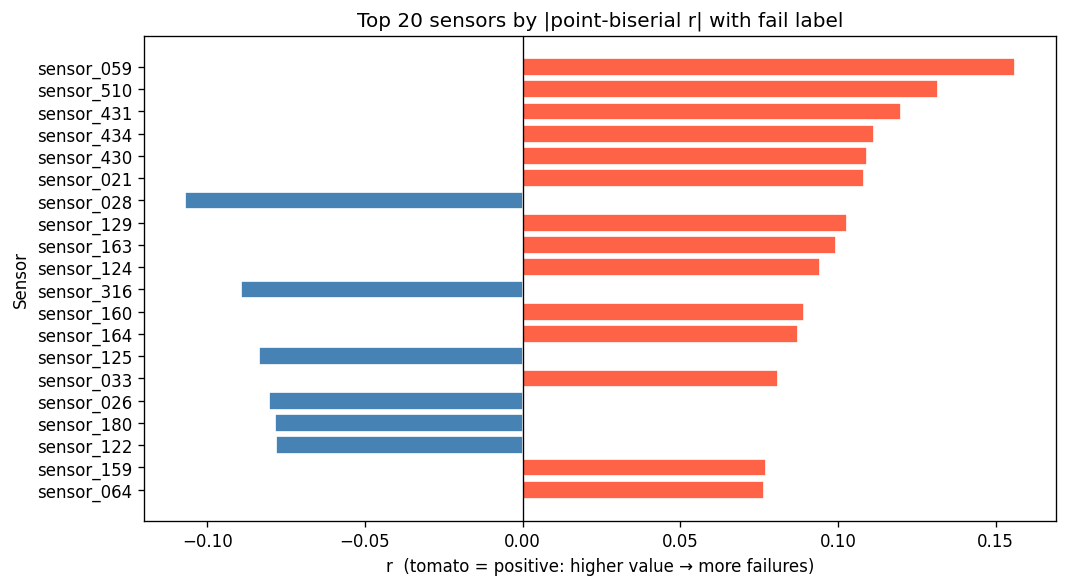

In [4]:
top20: pd.DataFrame = corr_df.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors: list[str] = ["tomato" if r > 0 else "steelblue" for r in top20["r"]]
ax.barh(
    top20["sensor"][::-1],
    top20["r"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 sensors by |point-biserial r| with fail label")
ax.set_xlabel("r  (tomato = positive: higher value → more failures)")
ax.set_ylabel("Sensor")
plt.tight_layout()

Correlations are modest throughout (max |r| ≈ 0.156 for `sensor_059`), consistent with the noisy nature of semiconductor process data. Most top sensors are positively correlated with failure — higher readings predict more failures — while a smaller group (`sensor_028`, `sensor_316`, `sensor_125`, `sensor_026`, `sensor_180`, `sensor_122`) shows the opposite direction. No single sensor dominates, which suggests Tier 3 will find distributed SHAP importance rather than a concentrated top-1 signal.

## 2  Sensor distributions by outcome

**Question:** Do the top-10 sensors show visually distinct pass/fail distributions, or is the separation subtle?

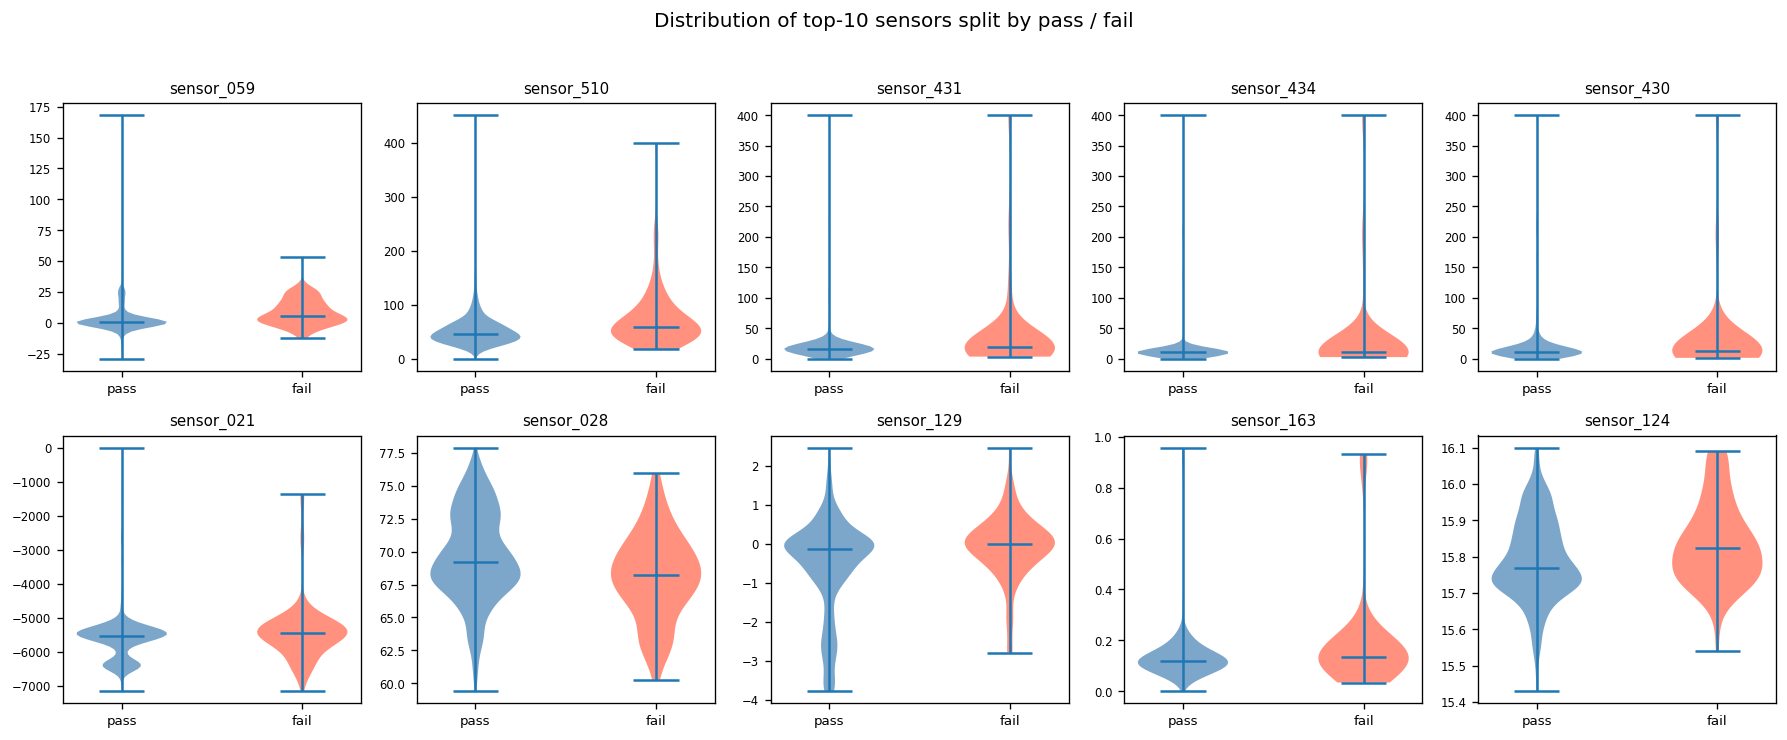

In [5]:
TOP10: list[str] = corr_df.head(10)["sensor"].tolist()

pass_df: pd.DataFrame = df[df["label"] == 0]
fail_df: pd.DataFrame = df[df["label"] == 1]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
flat_axes: list = axes.flatten().tolist()

for ax, sensor in zip(flat_axes, TOP10):
    pass_vals: np.ndarray = pass_df[sensor].dropna().values
    fail_vals: np.ndarray = fail_df[sensor].dropna().values
    parts: dict = ax.violinplot(
        [pass_vals, fail_vals],
        positions=[0, 1],
        showmedians=True,
    )
    body_colors: list[str] = ["steelblue", "tomato"]
    for body, color in zip(parts["bodies"], body_colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["pass", "fail"], fontsize=8)
    ax.set_title(sensor, fontsize=9)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Distribution of top-10 sensors split by pass / fail", y=1.02)
plt.tight_layout()

For `sensor_059`, `sensor_510`, `sensor_431`, and `sensor_434` the fail distribution is clearly shifted upward relative to pass, with minimal overlap in the upper tail — these sensors carry the most discriminative signal. For `sensor_028` and other negatively correlated sensors the shift is downward. The remaining sensors show substantial overlap despite their moderate |r| values, reinforcing that the model must combine many weak signals.

## 3  Summary table

Per-sensor correlation, mean pass value, mean fail value, and the raw mean difference (fail − pass) for all top-ranked sensors.

In [6]:
def build_summary(
    features: pd.DataFrame,
    target: pd.Series,
    corr: pd.DataFrame,
) -> pd.DataFrame:
    """Build a per-sensor summary of pass/fail mean values and correlation.

    Args:
        features: DataFrame of sensor readings, index-aligned with *target*.
        target: Binary series (0 = pass, 1 = fail).
        corr: Output of :func:`compute_correlations`; must contain ``sensor`` and ``r``.

    Returns:
        DataFrame with columns ``sensor``, ``r``, ``mean_pass``, ``mean_fail``,
        ``difference`` (fail − pass), sorted by ``abs_r`` descending.
    """
    pass_mask: pd.Series = target == 0
    fail_mask: pd.Series = target == 1

    rows: list[dict[str, object]] = []
    for _, row in corr.iterrows():
        sensor: str = str(row["sensor"])
        rows.append(
            {
                "sensor": sensor,
                "r": row["r"],
                "mean_pass": features.loc[pass_mask, sensor].mean(),
                "mean_fail": features.loc[fail_mask, sensor].mean(),
            }
        )

    summary: pd.DataFrame = pd.DataFrame(rows)
    summary["difference"] = summary["mean_fail"] - summary["mean_pass"]
    return summary


summary_df: pd.DataFrame = build_summary(df[SENSOR_COLS], TARGET, corr_df)
summary_df.head(20).style.format(
    {
        "r": "{:.4f}",
        "mean_pass": "{:.3f}",
        "mean_fail": "{:.3f}",
        "difference": "{:.3f}",
    }
)

,sensor,r,mean_pass,mean_fail,difference
0,sensor_059,0.1560,2.556,8.515,5.959
1,sensor_510,0.1317,54.430,74.348,19.918
2,sensor_431,0.1199,21.188,38.707,17.519
3,sensor_434,0.1113,13.717,28.955,15.238
4,sensor_430,0.1091,17.364,33.156,15.792
5,sensor_021,0.1083,-5636.360,-5363.822,272.538
6,sensor_028,-0.1070,69.598,68.112,-1.486
7,sensor_129,0.1028,-0.585,-0.083,0.503
8,sensor_163,0.0995,0.137,0.186,0.049
9,sensor_124,0.0942,15.792,15.835,0.043


## Hypotheses for Tier 3

These predictions are derived from the point-biserial correlations and mean-difference analysis above. Tier 3 should validate each against the SHAP global feature-importance bar chart and the root-cause triage rankings.

- **`sensor_059` will rank #1 or #2 in SHAP global importance** (r = 0.156, mean-fail ~3× mean-pass). It has the strongest univariate signal in the preprocessed feature set and a large absolute mean difference; a tree-based model should assign high SHAP weight to it.

- **`sensor_510`, `sensor_431`, `sensor_434`, and `sensor_430` will cluster in the top 10 SHAP features** (r ≈ 0.10–0.13, mean-fail 37–83% higher than mean-pass). Their moderate correlations and clear distributional shifts make them likely candidates for root-cause triage even if their individual SHAP values are lower than `sensor_059`.

- **`sensor_021` will appear in SHAP rankings despite its raw mean difference being hard to interpret** (r = 0.108, but means are in the −5 000 range with a fail−pass gap of ~273 units). The correlation is real; the large absolute scale means the mean difference is not directly comparable to other sensors.

- **Negatively correlated sensors (`sensor_028`, `sensor_316`, `sensor_125`, `sensor_026`, `sensor_180`, `sensor_122`) should show negative SHAP contributions** — high sensor values are associated with passing wafers, so the model should push predicted failure probability *down* when these sensors are elevated. Root-cause triage should flag *low* readings of these sensors as risk indicators, not high readings.

- **No single sensor should account for more than ~5–10% of SHAP variance.** The maximum |r| is only 0.156, and the sensor space is still 198 features after preprocessing. Expect a long tail of small SHAP contributions rather than a clean 'top cause'.

- **`sensor_160` and `sensor_159` may rank higher in tree-based SHAP than their |r| suggests** (r ≈ 0.077–0.089, but mean-fail values are 38–35% larger than mean-pass). Tree models can exploit non-linear threshold effects that point-biserial correlation does not capture.